# The Tacoma scene from a LEO pass — minimum viable

This notebook renders DIRSIG's bundled **Tacoma** scene (Port of Tacoma, WA) as seen by a
sensor riding a real WorldView-2 pass. It is deliberately thin. Almost every piece was built
and verified in an earlier notebook, and here it is **imported**, not rebuilt:

| Piece | Where it was built and checked | How it gets here |
|---|---|---|
| Sensor tree (mount → instrument → focal plane → detector array) | `tutorial_dirfm_basics.ipynb` Stages 1 and 3 | `protodirsig.sensors` |
| Minimal atmosphere | `tutorial_dirfm_basics.ipynb` Stage 1 | `protodirsig.sensors.simple_atmosphere` |
| TLE fetch, SGP4, TEME → ITRS and its three checks, geodesy, the fixed `up`-vector check, ECEF waypoints | `tutorial_orbit_to_ground.ipynb` Stage 1 | `protodirsig.orbit` |
| Read-only scene reference (XML copy + asset symlinks) and the install fingerprint guard | this notebook (Phase 3), shared with `scripts/crosscheck_sgp4.py` | `protodirsig.scene_ref` |
| Band coverage of a referenced scene's real materials (dirfm's check is vacuous here) | this notebook (Phase 3, by hand), made reusable in Phase 4b | `protodirsig.scene_coverage` |

`src/protodirsig/` was factored out of those notebooks for this purpose.
`tests/test_orbit.py` confirms that the module reproduces Phase 2's Rochester pass exactly:
the same pass, closest approach, `UP_VECTOR` and interpolation error.

**What is new** is referencing a scene someone else built, instead of authoring one with
dirfm's geometry classes. There are also two consequences of this particular scene: it is
under 1 km across, and it lives in a directory we must not write to.

| Stage | What it does |
|---|---|
| 0 | Reference `tacoma.scene`; check its real materials cover the band (`scene_coverage`) |
| 1 | A WorldView-2 pass over Tacoma, the pointing, and the per-pass `up` check |
| 2 | Assemble, render, confirm the install is untouched, and check the truth image against the prediction |

---
# Stage 0 — Referencing the Tacoma scene

## Environment

This follows the same convention as the other two notebooks: `DIRSIG_HOME` is read from the
environment, with this machine's install as the documented fallback, and its `bin/` is
prepended to `PATH`. `protodirsig` is imported from `src/`. If the package has not been
`pip install -e .`'d into the environment, `src/` is put on `sys.path` instead, so the notebook
runs either way.

In [1]:
import os
import shutil
import sys
from pathlib import Path

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT / "outputs"
IN_DIR, OUT_DIR = OUTPUTS / "tacoma_scene_input", OUTPUTS / "tacoma_scene_output"
DATA_DIR = OUTPUTS / "_orbit_data"                       # Phase 2's TLE / ephemeris cache

try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig
from protodirsig import orbit, sensors

TACOMA = DIRSIG_HOME / "Tacoma-08-Apr-2022" / "Tacoma"   # read-only reference
print("DIRSIG_HOME :", DIRSIG_HOME)
print("protodirsig :", Path(protodirsig.__file__).parent)
print("Tacoma      :", TACOMA, "exists" if (TACOMA / "tacoma.scene").is_file() else "MISSING")
assert (TACOMA / "tacoma.scene").is_file()

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
protodirsig : /home/kevin-kearney/dev/protoDIRSIG/src/protodirsig
Tacoma      : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64/Tacoma-08-Apr-2022/Tacoma exists


## The scene reference: dirfm's `_fname` escape hatch

A DIRSIG job never needs a scene's *contents* in Python. The `.jsim`'s `scene_list` holds a
**path** to a `.scene` file, which `scene2hdf` compiles and `dirsig5` renders. FINDINGS.md
("Referencing a pre-existing scene") covers the argument in full. dirfm has an escape hatch
that fits this: `SCENE.write()` begins with
`if self._fname is not None: return self._fname`. If we set `_fname` ourselves, a bare
`SCENE` stands in for an existing file, and none of dirfm's geometry or material
serialisation runs.

This is a **private-attribute assignment against an escape hatch in dirfm's `write()`, not a
documented public API**. It works because of how `write()` happens to be written, and a future
dirfm could break it.

### Why `_fname` does not point *into* the Tacoma directory

The obvious move is `_fname = TACOMA / "tacoma.scene"`. It would render, but it breaks the
rule that the DIRSIG install is read-only. **`scene2hdf` writes its output next to the
`.scene` file it is given** and has no option to put it anywhere else (`scene2hdf --help`
lists none). For Tacoma that output is `tacoma.scene.hdf`, about 650 MB, plus an
`asset_report.txt`, both written into the install. Pointing `_fname` at a *symlink* to
`tacoma.scene` does not help. `scene2hdf` resolves the link and still writes beside the real
file, while `dirsig5` looks beside the link and fails. Both behaviours were confirmed while
building this notebook and are recorded in FINDINGS.md.

The approach used instead writes nothing into the install. `outputs/tacoma_scene_input/tacoma_ref/`
gets a **copy of the 3.4 KB `tacoma.scene` XML file only**, unmodified, plus **symlinks**
named `geometry`, `materials` and `maps` pointing at the originals. The scene resolves every
asset through `$SCENE_DIR/geometry`, `$SCENE_DIR/materials/…` and `$SCENE_DIR/maps/`, so
DIRSIG reads the real, uncopied assets in place, and `scene2hdf`'s output lands beside the
copy, under `outputs/`, which is gitignored. The cell asserts that the copy is byte-identical
to the original. Stage 2 fingerprints the whole Tacoma tree before and after the render and
asserts that nothing changed.

### The known side effect: dirfm's coverage check has nothing to check

`DIRSIG.write_files()` calls `scene._check_coverage(band_min, band_max)` on every scene. A bare
`SCENE` knows only dirfm's default placeholder material, `Dummy`, not Tacoma's `tacoma.mat`.
FINDINGS.md expected that call to raise, which upstream turns into a logged warning. The cell
below calls it directly. It returns silently for the visible band **and for an absurd 5–50 µm
band**, because `Dummy` has no surface properties for the check to iterate over. So the check
passes vacuously. It says nothing about Tacoma either way, and the next section checks
`tacoma.mat` directly, using `protodirsig.scene_coverage`.

In [2]:
import lxml.etree as et
from dirfm import SCENE
from protodirsig.scene_ref import reference_scene

REF_DIR = IN_DIR / "tacoma_ref"
# XML copy (asserted byte-identical) + symlinks geometry/, materials/, maps/ -> the originals.
ref_file = reference_scene(TACOMA / "tacoma.scene", REF_DIR)

tacoma_scene = SCENE("tacoma")
tacoma_scene._fname = ref_file                     # private attribute: write() returns it as-is

scene_xml = et.parse(str(REF_DIR / "tacoma.scene")).getroot()
loc = scene_xml.find("sceneorigin/location")
TAC_LAT, TAC_LON, TAC_ALT = (float(loc.findtext(k)) for k in ("latitude", "longitude", "altitude"))
features = scene_xml.find("properties").get("features")
print(f"scene reference : {tacoma_scene._fname}  (write() -> {tacoma_scene.write({})})")
print(f"scene origin    : {loc.get('frame')} {TAC_LAT}, {TAC_LON}, {TAC_ALT} m")
print(f"features        : {features}")
print(f"geometry lists  : {[g.text for g in scene_xml.iterfind('geometrylist/geometrylistinclude')]}")

print("\ndirfm coverage check on the bare SCENE:")
for band in [(0.4, 0.7), (5.0, 50.0)]:
    print(f"  {band[0]}-{band[1]} um ->", tacoma_scene._check_coverage(*band), "(no exception)")
print("  materials it checked:", [m._name for m in tacoma_scene._material._mats])
assert (TAC_LAT, TAC_LON, TAC_ALT) == (47.27, -122.41, 0.0)

Material [Dummy] ID has already been set to [N/A], can't override.


scene reference : /home/kevin-kearney/dev/protoDIRSIG/outputs/tacoma_scene_input/tacoma_ref/tacoma.scene  (write() -> /home/kevin-kearney/dev/protoDIRSIG/outputs/tacoma_scene_input/tacoma_ref/tacoma.scene)
scene origin    : geodetic 47.27, -122.41, 0.0 m
features        : vis,nir
geometry lists  : ['terrain.odb', 'tacoma.odb', 'targets.glist']

dirfm coverage check on the bare SCENE:
  0.4-0.7 um -> None (no exception)
  5.0-50.0 um -> None (no exception)
  materials it checked: ['Dummy']


## Band coverage, checked against `tacoma.mat` directly

The scene declares `features="vis,nir"`, and dirfm's own check (above) passes for any band, so
neither can be trusted. `protodirsig.scene_coverage` reads the material database the `.scene`
actually points at (`<matfilename>`, with files resolved through `<emsdirectory>`) and
reports, per material, the wavelength span it is defined over. Each `MATERIAL_ENTRY` in
`tacoma.mat` gets its spectral behaviour in one of three ways:

* **inline Ward BRDF weights** (`DS_WEIGHTS`), with no wavelength dependence, which is valid at
  any wavelength;
* **`.ems` curve files** (`ClassicEmissivity`'s `FILENAME`, `ShellTarget`'s
  `EMISSIVITY_FILE`). These are two-column `wavelength  value` tables. Some hold hundreds of
  curves, so the helper splits every file into its curves and uses the **narrowest** span;
* **Shell-target `.fit` files** (`BRDF_FIT_FILE`), which have `LAMBDA` entries in µm.

The helper **fails closed**. A surface property or file reference it does not recognise
marks that material *unknown*, and `covers()` is then False for every band. It therefore
cannot repeat dirfm's silent pass. `tests/test_scene_coverage.py` pins the Tacoma result
below, so a future scene reference has a known-good case to compare against.

The cell also lists the texture maps declared in the `.scene`, which apply only inside their
own `<bandpass>`, and reads the extent of the scene's ground mesh. The ground's size and
centre decide both the pointing (Stage 1) and the sensor footprint (Stage 2). Everything is
read through `REF_DIR`, so it is the same data DIRSIG will read.

In [3]:
import re
import numpy as np
from protodirsig.scene_coverage import scene_coverage

BAND = (0.4, 0.7)                                      # the RGB band Stage 2 renders
cov = scene_coverage(ref_file)
files = {f: v for m in cov.materials for f, v in m.files.items()}
print(f"{cov.mat_file.name}: {len(cov.materials)} materials, "
      f"{sum(not m.files for m in cov.materials)} wavelength-independent (inline WardBRDF), "
      f"{len(files)} spectral files, {len(cov.unknown)} unknown")
for f, (lo, hi, n) in sorted(files.items()):
    print(f"  {f:34s} {lo:6.3f} .. {hi:7.3f} um  ({n} {'curves' if f.endswith('.ems') else 'LAMBDA pts'})")
print(f"\nband covered by EVERY material: {cov.span[0]:.3f} .. {cov.span[1]:.3f} um")
print(f"covers {BAND[0]}-{BAND[1]} um: {cov.covers(*BAND)}")
print(f"covers 0.4-0.9 um ('nir'): {cov.covers(0.4, 0.9)}  -- gaps: "
      f"{sorted({f for m in cov.gaps(0.4, 0.9) for f in m.files if files[f][1] < 0.9})}")
for name, matid, lo, hi in cov.texture_bands:
    print(f"texture map '{name}' (mat {matid}): {lo}-{hi} um")
assert cov.covers(*BAND), [m.name for m in cov.gaps(*BAND)]

# Ground extent: the ground mesh's vertices, placed by terrain.odb's instance translation.
verts = np.array([[float(v) for v in ln.split()[1:4]]
                  for ln in (REF_DIR / "geometry" / "ground_large.obj").read_text().splitlines() if ln.startswith("v ")])
inst = re.search(r"OBJ_FILENAME\s*=\s*ground_large\.obj.*?INFO\s*=\s*([^\n]+)",
                 (REF_DIR / "geometry" / "terrain.odb").read_text(), flags=re.S).group(1)
GROUND_C = np.array([float(v) for v in inst.split(",")[:3]])
GROUND_HALF = float(np.abs(verts[:, :2]).max())
print(f"\nground mesh: {2 * GROUND_HALF:.1f} m square centred at scene ENU "
      f"({GROUND_C[0]:.3f}, {GROUND_C[1]:.3f}) m")

tacoma.mat: 42 materials, 18 wavelength-independent (inline WardBRDF), 21 spectral files, 0 unknown
  asphalt_mixed_v2.ems                0.400 ..  14.286 um  (300 curves)
  brick_charlestowne.ems              0.350 ..  25.050 um  (2 curves)
  cream_rgb.ems                       0.400 ..   1.000 um  (1 curves)
  dark_orange_panel.ems               0.400 ..   0.800 um  (1 curves)
  dk_clothes.ems                      0.380 ..  13.000 um  (1 curves)
  drkblue_rgb.ems                     0.400 ..   1.000 um  (1 curves)
  flesh.ems                           0.380 ..  13.000 um  (1 curves)
  grass_mixed.ems                     0.400 ..  14.286 um  (300 curves)
  green_rgb.ems                       0.400 ..   1.000 um  (1 curves)
  lt_blue_panel.ems                   0.385 ..   0.780 um  (1 curves)
  lt_clothes.ems                      0.380 ..  13.000 um  (1 curves)
  ltred_rgb.ems                       0.400 ..   1.000 um  (1 curves)
  matte.fit                           0.400 ..  10.400 u

**Result.** Every spectral file starts at or below 0.40 µm, and the narrowest ends at 0.78 µm
(`lt_blue_panel.ems`). The inline Ward materials have no wavelength dependence. So **the
0.4–0.7 µm visible band is fully covered.** It is also exactly the band of the scene's two ground texture maps, which
would stop applying outside it. Stage 2 therefore uses the basics notebook's Stage 3 RGB
channels (0.4–0.7 µm) unchanged. Nothing had to be narrowed to fit.

The scene's `features="vis,nir"` is *not* backed by every material. `lt_blue_panel`
(0.78 µm), `orange_panel` and `dark_orange_panel` (0.80 µm) stop short of most of the NIR,
and the ground textures are defined only to 0.7 µm. This notebook doesn't render NIR, so it
doesn't matter here. A NIR channel on this scene would first need to know what DIRSIG does
past the end of a curve.

The scene's ground is a single **914.4 m square**, not a large terrain, and it sits off the
scene origin. That fact drives everything in Stage 1.

---
# Stage 1 — A WorldView-2 pass over Tacoma

This is Phase 2's pipeline with a different target, run through `protodirsig.orbit`. The
TLE is fetched from the Phase 2 cache and validated (checksums, name, international
designator). Passes are chosen by the same rule: the highest daylight culmination within
7 days of the TLE epoch, with elevation ≥ 30° and Sun ≥ 20°. The window is 120 s centred on
culmination and starts at `PASS_EPOCH`. SGP4 runs through skyfield into ITRS. The TEME → ITRS
conversion is re-checked by the same function, which tests the z-invariance, the angle against
GMST-82 and the rotation rate. Why those checks, and why TEME must never be treated as ECEF, is
in FINDINGS.md ("Correctness traps") and Phase 2 Stage 1. It isn't re-argued here.

The ground-track plot is the independent check that this pass really brings WorldView-2 over
Tacoma before anything is wired into dirfm.

TLE epoch 2026-09-22T14:00:09Z  (WORLDVIEW-2 (WV-2))
16 passes >= 30 deg; 8 in daylight
chosen    2026-09-28T19:14:53Z  max elevation 84.9 deg, sun 39.5 deg, TLE age 6.22 d
PASS_EPOCH 2026-09-28T19:13:53+00:00  (frame at t = 60 s)
TEME->ITRS checks: |dz| 0.0e+00 m, vs GMST82 3.1e-04", rate 7.2921158e-05 rad/s
height 773.8..775.6 km; sub-satellite point passes 61.7 km from Tacoma at t = 59.86 s


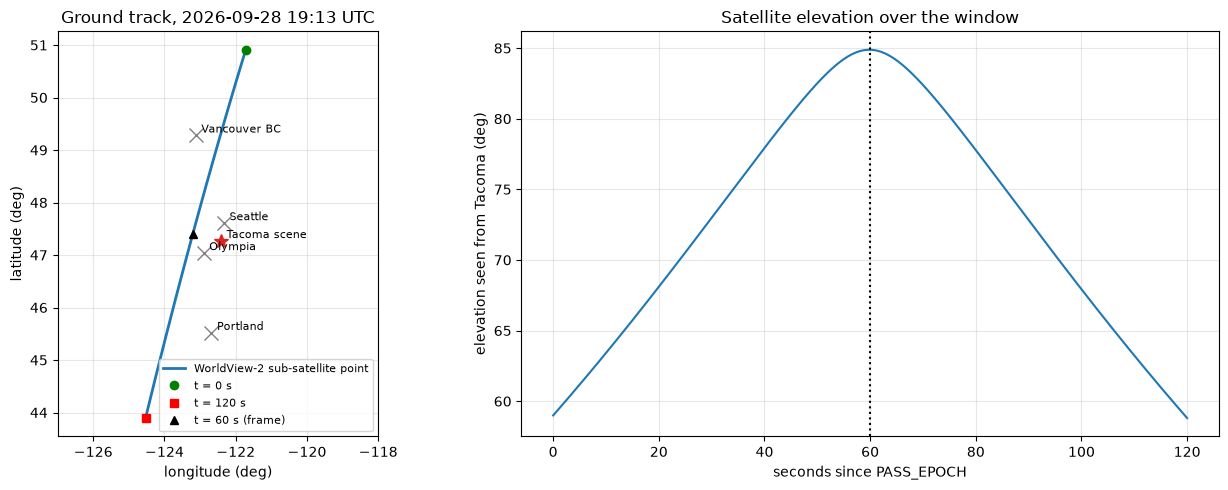

In [4]:
import matplotlib.pyplot as plt
from skyfield.api import EarthSatellite, Loader, wgs84

_, sat_name, line1, line2 = orbit.fetch_tle(35946, DATA_DIR, expect_name="WORLDVIEW-2", expect_intl="09055A")
load = Loader(DATA_DIR, verbose=False)
ts = load.timescale()
sat = EarthSatellite(line1, line2, sat_name, ts)
planets = load("de421.bsp")
TARGET = wgs84.latlon(TAC_LAT, TAC_LON)                 # the scene's own origin

candidates = orbit.find_passes(sat, TARGET, planets["earth"], planets["sun"])
t_culm, culm_el, culm_sun = orbit.choose_pass(candidates)
PASS_DURATION, DENSE_DT, FRAME_T = 120.0, 0.01, 60.0
PASS_EPOCH = orbit.pass_epoch(t_culm, PASS_DURATION)
t = np.arange(round(PASS_DURATION / DENSE_DT) + 1) * DENSE_DT
times, geo, pos, pos_teme = orbit.propagate(sat, ts, PASS_EPOCH, t)
chk = orbit.check_teme_to_itrs(pos, pos_teme, times, t)
lat, lon, alt = orbit.ecef_to_geodetic(pos)
dist = orbit.ground_km(lat, lon, TAC_LAT, TAC_LON)
k = int(round(FRAME_T / DENSE_DT))

print(f"TLE epoch {sat.epoch.utc_iso()}  ({sat_name})")
print(f"{len(candidates)} passes >= 30 deg; {sum(c[2] >= 20 for c in candidates)} in daylight")
print(f"chosen    {t_culm.utc_iso()}  max elevation {culm_el:.1f} deg, sun {culm_sun:.1f} deg, "
      f"TLE age {t_culm - sat.epoch:.2f} d")
print(f"PASS_EPOCH {PASS_EPOCH.isoformat()}  (frame at t = {FRAME_T:g} s)")
print(f"TEME->ITRS checks: |dz| {chk['max_dz_m']:.1e} m, vs GMST82 {chk['max_gmst_err_arcsec']:.1e}\", "
      f"rate {chk['rate_rad_s']:.7e} rad/s")
print(f"height {alt.min() / 1e3:.1f}..{alt.max() / 1e3:.1f} km; sub-satellite point passes "
      f"{dist.min():.1f} km from Tacoma at t = {t[dist.argmin()]:.2f} s")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.3]})
a1.plot(lon, lat, lw=2, label="WorldView-2 sub-satellite point")
a1.plot(lon[0], lat[0], "go", label="t = 0 s"); a1.plot(lon[-1], lat[-1], "rs", label=f"t = {t[-1]:.0f} s")
a1.plot(lon[k], lat[k], "k^", label=f"t = {FRAME_T:g} s (frame)")
for cname, (clat, clon) in {"Tacoma scene": (TAC_LAT, TAC_LON), "Seattle": (47.61, -122.33),
                            "Olympia": (47.04, -122.90), "Portland": (45.52, -122.68),
                            "Vancouver BC": (49.28, -123.12)}.items():
    a1.plot(clon, clat, "*" if cname.startswith("Tacoma") else "x", color="C3" if cname.startswith("Tacoma") else "gray", ms=10)
    a1.annotate(cname, (clon, clat), xytext=(4, 2), textcoords="offset points", fontsize=8)
a1.set(xlabel="longitude (deg)", ylabel="latitude (deg)", title=f"Ground track, {PASS_EPOCH:%Y-%m-%d %H:%M} UTC")
a1.set(xlim=(-127, -118)); a1.set_aspect(1 / np.cos(np.radians(TAC_LAT)))
a1.grid(alpha=0.3); a1.legend(fontsize=8, loc="lower right")
el_deg = (sat - TARGET).at(times).altaz()[0].degrees
a2.plot(t, el_deg); a2.axvline(FRAME_T, color="k", ls=":")
a2.set(xlabel="seconds since PASS_EPOCH", ylabel="elevation seen from Tacoma (deg)",
       title="Satellite elevation over the window"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

assert culm_el > 80 and dist.min() < 100 and abs(t[dist.argmin()] - FRAME_T) < 2

**The pass does go over Tacoma.** It culminates about 85° above Tacoma's horizon, and the
ground track runs about 60 km to one side. At 770 km altitude that is only about 5° off
straight down.

## Pointing: stare at the scene, not nadir

Those 60 km matter here in a way they did not in Phase 2. There, the substitute scene was
built *around* wherever the nadir boresight landed. Tacoma is fixed and only **914 m across**.
A nadir LookAt would put the boresight about 60 km from the port, so the frame would hold
nothing but the scene's open-water backdrop, a 20 km `BOX` just below the ground mesh (see Stage 2). The cell measures
this. So the LookAt aims at a **fixed point in the scene**, the centre of the ground mesh,
using a dirfm `ENUFrame` (written as `frame="scene"`) in place of Phase 2's `ECEFFrame(0, 0, 0)`.
This is not an invention for this notebook. It is how DIRSIG's own authors imaged this scene
from orbit: `shots/oct17/skysat1-oct17.motion` in the Tacoma bundle uses exactly this
`<orientationengine type="lookat">` with a fixed `frame="scene"` location. A real WorldView-2
points off nadir to image a target, so staring is also the more faithful choice.

**The `up` vector, re-derived for this pass.** Phase 2's numeric `UP_VECTOR` belonged to a
different ground track. The *method* carries over unchanged: take the fixed along-track `up`
from this pass's ITRS velocity at the frame time, then run `orbit.up_vector_check` over all
12,001 samples. The boresight is now satellite → aim point, so it swings about ±30° along-track
across the 120 s window instead of staying near vertical. The angle between `up` and the
boresight therefore ranges well away from Phase 2's ≈ 90°. The criterion is the one that
matters, that roll must stay well defined, so `up` must stay far from parallel to the
boresight. We require at least 30° of margin at every sample, and roll within 2° of true
velocity-up.

In [5]:
from dirfm import frames

ECEF_TO_ENU = orbit.ecef_to_enu_matrix(TAC_LAT, TAC_LON)
origin_ecef = TARGET.itrs_xyz.m                         # scene origin at WGS-84 height 0
AIM = [round(float(v), 3) for v in GROUND_C]            # ground-mesh centre, scene ENU
aim_ecef = origin_ecef + ECEF_TO_ENU.T @ np.array(AIM)

vel_enu = np.gradient(pos, t, axis=0) @ ECEF_TO_ENU.T
los = aim_ecef - pos
slant = np.linalg.norm(los, axis=1)
bore = (los / slant[:, None]) @ ECEF_TO_ENU.T           # stare boresight, scene ENU
UP_VECTOR = orbit.along_track_up(vel_enu, k)
ang, roll = orbit.up_vector_check(UP_VECTOR, bore, vel_enu)
margin = np.minimum(ang, 180 - ang)                     # degrees away from (anti)parallel

nadir = -pos[k] / np.linalg.norm(pos[k])                # what Phase 2's nadir LookAt would do
U = ECEF_TO_ENU[2]
s_n = np.dot(origin_ecef - pos[k], U) / np.dot(nadir, U)
nadir_hit = ECEF_TO_ENU @ (pos[k] + s_n * nadir - origin_ecef)
off_nadir = np.degrees(np.arccos(np.dot(nadir, los[k] / slant[k])))

print(f"aim point (ground centre) : scene ENU {AIM}")
print(f"nadir LookAt would land   : E {nadir_hit[0] / 1e3:,.1f} km, N {nadir_hit[1] / 1e3:,.1f} km "
      f"-> {np.hypot(*(nadir_hit[:2] - GROUND_C[:2])) / 1e3:.1f} km from a {2 * GROUND_HALF:.0f} m scene")
print(f"stare at t = {FRAME_T:g} s          : slant {slant[k] / 1e3:.2f} km, {off_nadir:.2f} deg off nadir")
print(f"UP_VECTOR (scene ENU)     : {UP_VECTOR}")
print(f"  angle to boresight      : {ang.min():.1f} .. {ang.max():.1f} deg  (min margin from parallel {margin.min():.1f} deg)")
print(f"  roll vs velocity-up     : {roll.min():.2f} .. {roll.max():.2f} deg")
assert margin.min() > 30 and roll.max() < 2.0

t_wp, pos_wp, chord = orbit.thin(t, pos, DENSE_DT, 1.0)
orbit_motion = orbit.lookat_motion(t_wp, pos_wp, frames.ENUFrame(*AIM), UP_VECTOR)
print(f"\n{len(t_wp)} ECEF waypoints at 1 s (max linear-interpolation error {chord:.2f} m); LookAt -> scene {AIM}")

aim point (ground centre) : scene ENU [-145.313, 183.109, 0.0]
nadir LookAt would land   : E -59.8 km, N 18.1 km -> 62.2 km from a 914 m scene
stare at t = 60 s          : slant 777.43 km, 4.59 deg off nadir
UP_VECTOR (scene ENU)     : [-0.271137, -0.962541, 0.0]
  angle to boresight      : 59.4 .. 120.8 deg  (min margin from parallel 59.2 deg)
  roll vs velocity-up     : 0.00 .. 0.75 deg

121 ECEF waypoints at 1 s (max linear-interpolation error 1.00 m); LookAt -> scene [-145.313, 183.109, 0.0]


---
# Stage 2 — Assemble, render, and check against the truth image

**Sensor.** The basics notebook's Stage 3 `make_rgb_camera(focal, nx, ny, pitch)` is used
unchanged, with the same tree and 0.4–0.7 µm R/G/B channels. Only its size arguments differ,
and they are chosen so one frame holds the whole 914 m scene: 8 µm pixels (as before),
**3000 mm** focal length and **512 × 512** pixels. At the ~777 km slant range that gives about
**2.1 m GSD** and a ~1.06 km footprint. That holds the 914 m ground square when the square is
aligned with the frame. The fixed along-track `up` rolls the image about 16° relative to
North, though, and a square rotated by θ spans side × (cos θ + sin θ). At this roll that is
about 1.13 km, so two corners of the ground clip slightly. The cell prints the prediction, and
the truth image measures what is actually in frame. That
is coarser than WorldView-2's real 0.46 m pan, but it is the resolution at which the whole port
fits in one frame.

**Atmosphere.** This is basics Stage 1's `BasicAtmospherePlugin` + `SimpleRadiativeTransfer`,
unchanged. As in Phase 2, it gives a recognizable image, not a physically faithful model of a
path from orbit through the whole atmosphere.

**`TASKS`.** The reference datetime is `PASS_EPOCH`, since the waypoints are
`datetime="relative"` to it. There is one frame at `t = 60 s`, the culmination, following
`StkImport1`'s `demo.tasks` single-frame convention as in Phase 2. The 120 s motion window is
the pass, and the frame samples its midpoint.

**Guarding the read-only install.** Before `run()`, the cell fingerprints every path under the
Tacoma bundle (name, size, mtime, mode), using `protodirsig.scene_ref.fingerprint`. Afterwards it asserts that the fingerprint is
identical, and that `scene2hdf`'s output landed in `tacoma_ref/`. The cell also records what
dirfm logs during `write_files()`, to show what its coverage check actually said.

**The truth check.** The `Intersection` truth image records, for every pixel, the scene ENU
point its ray hit. The camera stares at `AIM`, so the **centre** of the frame must hit `AIM`
to within about a pixel. A solid object at the aim point would move the hit horizontally by
its height × tan(off-nadir), which is centimetres at 4.6° for a low object. The truth image
also tells us which pixels hit the Tacoma ground mesh and which hit the backdrop outside it.

In [6]:
import logging
import time
from dirfm import DIRSIG, TASKS
from spectral import open_image

FOCAL_MM, NPIX, PITCH_UM = 3000, 512, 8
GSD = slant[k] * PITCH_UM * 1e-6 / (FOCAL_MM * 1e-3)
ROLL = np.degrees(np.arctan2(UP_VECTOR[0], UP_VECTOR[1])) % 90            # square vs frame rotation
span = 2 * GROUND_HALF * (np.cos(np.radians(ROLL)) + np.sin(np.radians(ROLL)))
print(f"GSD {GSD:.2f} m, footprint {NPIX * GSD:,.0f} m square; ground square rotated {ROLL:.1f} deg "
      f"in the frame spans {span:,.0f} m -> {'fits' if span <= NPIX * GSD else 'corners clip'}")
assert 2 * GROUND_HALF <= NPIX * GSD                     # fits when aligned; roll clips only corners


from protodirsig.scene_ref import fingerprint


class Capture(logging.Handler):
    def __init__(self):
        super().__init__(logging.DEBUG); self.records = []
    def emit(self, record):
        self.records.append(f"{record.name}: {record.getMessage()}")


cap = Capture()
dirfm_log = logging.getLogger("dirfm")
dirfm_log.addHandler(cap); dirfm_log.setLevel(logging.INFO)

camera = sensors.make_rgb_camera(focal=FOCAL_MM, nx=NPIX, ny=NPIX, pitch=PITCH_UM)
job = DIRSIG(IN_DIR, OUT_DIR)
job.add_plugin(sensors.simple_atmosphere())
job.add_plugin(camera.set_motion(orbit_motion).set_tasks(TASKS(PASS_EPOCH).add_start_stop(FRAME_T, FRAME_T)))
job.add_scene(tacoma_scene, [0, 0, 0])

before = fingerprint(TACOMA.parent)
t0 = time.perf_counter()
job.run()
elapsed = time.perf_counter() - t0
after = fingerprint(TACOMA.parent)
dirfm_log.removeHandler(cap)

print(f"run() {elapsed:.0f} s")
print(f"Tacoma bundle fingerprint: {len(before)} paths, unchanged = {before == after}")
print(f"scene2hdf output         : {sorted(p.name for p in REF_DIR.iterdir() if not p.is_symlink())}")
cov = [r for r in cap.records if "coverage" in r.lower()]
print("dirfm coverage-check log :", *cov, sep="\n  ")
print("dirfm 'does not support' :", [r for r in cap.records if "does not support" in r] or "none")
assert before == after, "the Tacoma bundle changed during the run"
assert (REF_DIR / "tacoma.scene.hdf").is_file()

GSD 2.07 m, footprint 1,061 m square; ground square rotated 15.7 deg in the frame spans 1,128 m -> corners clip


run() 31 s
Tacoma bundle fingerprint: 155 paths, unchanged = True
scene2hdf output         : ['asset_report.txt', 'tacoma.scene', 'tacoma.scene.hdf']
dirfm coverage-check log :
  dirfm.dirsig: Testing scene coverage for band [0.4-0.7] from Mount-Instrument-FPA
dirfm 'does not support' : none


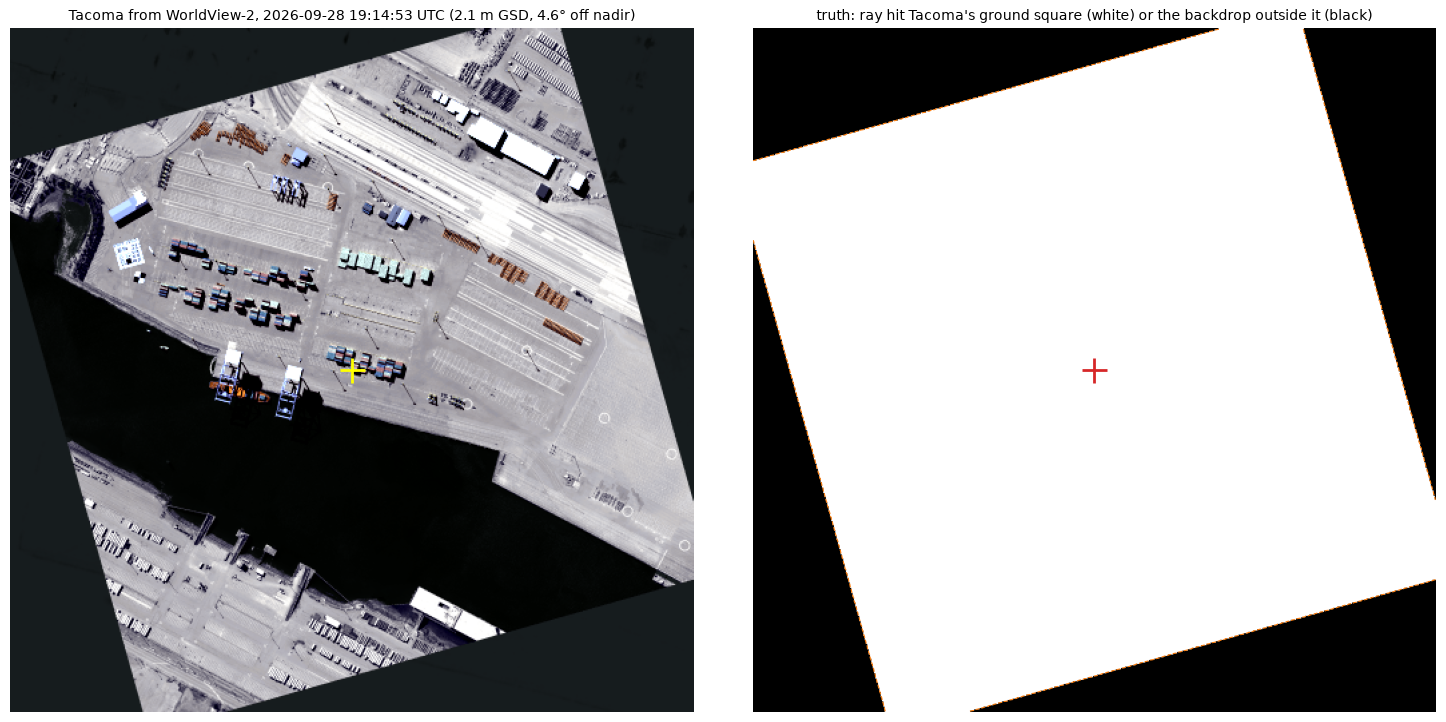

radiance cube (512, 512, 3); truth misses (NaN): 0.0%
frame centre hits scene ENU (-145.57, 183.22) m; aim (-145.313, 183.109) m -> 0.28 m = 0.14 px
pixels on the 914 m ground square: 73.2%; backdrop outside it at z = -0.100 .. -0.038 m
truth footprint extent: X 1,311 m, Y 1,308 m (predicted 1,061 m square, rotated)
ground square visible in frame: ~98.7%
frame-centre radiance [0. 0. 0.] at truth z = -0.000 m
exactly-zero radiance pixels: 0.77%; their truth z median 0.000 m, 100% on the ground square


In [7]:
rgb = np.asarray(open_image(str(OUT_DIR / "demo.img.hdr")).load(), dtype=float)
tr = open_image(str(OUT_DIR / "truth.img.hdr"))
truth = {n: np.asarray(tr.read_band(i), dtype=float) for i, n in enumerate(tr.metadata["band names"])}
X, Y, Z = (truth[f"Scene ENU {a} Coordinate [m]"] for a in "XYZ")


def stretch(b, lo=2, hi=98):
    a, c = np.percentile(b, [lo, hi])
    return np.clip((b - a) / max(c - a, 1e-12), 0, 1)


c0 = NPIX // 2
cx, cy = X[c0 - 1:c0 + 1, c0 - 1:c0 + 1].mean(), Y[c0 - 1:c0 + 1, c0 - 1:c0 + 1].mean()   # the 4 centre pixels
centre_err = np.hypot(cx - AIM[0], cy - AIM[1])
on_ground = (np.abs(X - GROUND_C[0]) <= GROUND_HALF) & (np.abs(Y - GROUND_C[1]) <= GROUND_HALF)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 7.2))
a1.imshow(np.dstack([stretch(rgb[:, :, b]) for b in range(3)]))
a1.plot(c0 - 0.5, c0 - 0.5, "+", color="yellow", ms=18, mew=2)
a1.set_title(f"Tacoma from WorldView-2, {PASS_EPOCH:%Y-%m-%d} {times[k].utc_strftime('%H:%M:%S')} UTC "
             f"({GSD:.1f} m GSD, {off_nadir:.1f}° off nadir)", fontsize=10)
a1.axis("off")
a2.imshow(on_ground, cmap="gray")
a2.contour(Z, levels=[-0.05], colors="C1", linewidths=0.8)
a2.plot(c0 - 0.5, c0 - 0.5, "+", color="C3", ms=18, mew=2)
a2.set_title("truth: ray hit Tacoma's ground square (white) or the backdrop outside it (black)", fontsize=10)
a2.axis("off")
plt.tight_layout(); plt.show()

print(f"radiance cube {rgb.shape}; truth misses (NaN): {np.isnan(X).mean():.1%}")
print(f"frame centre hits scene ENU ({cx:.2f}, {cy:.2f}) m; aim ({AIM[0]}, {AIM[1]}) m "
      f"-> {centre_err:.2f} m = {centre_err / GSD:.2f} px")
print(f"pixels on the {2 * GROUND_HALF:.0f} m ground square: {on_ground.mean():.1%}; "
      f"backdrop outside it at z = {np.nanmin(Z[~on_ground]):.3f} .. {np.nanmax(Z[~on_ground]):.3f} m")
print(f"truth footprint extent: X {np.nanmax(X) - np.nanmin(X):,.0f} m, Y {np.nanmax(Y) - np.nanmin(Y):,.0f} m "
      f"(predicted {NPIX * GSD:,.0f} m square, rotated)")
zero = rgb.sum(axis=2) == 0
print(f"ground square visible in frame: ~{on_ground.mean() * (NPIX * GSD) ** 2 / (2 * GROUND_HALF) ** 2:.1%}")
print(f"frame-centre radiance {rgb[c0, c0]} at truth z = {Z[c0, c0]:.3f} m")
print(f"exactly-zero radiance pixels: {zero.mean():.2%}; their truth z median {np.median(Z[zero]):.3f} m, "
      f"{on_ground[zero].mean():.0%} on the ground square")
assert centre_err < GSD, "frame centre is more than a pixel from the aim point"
assert on_ground[c0, c0]

### What the image shows, checked rather than asserted

* **The Tacoma scene appears where the pointing puts it.** The four centre pixels hit the scene
  **0.28 m** from `AIM`, the ground-mesh centre the LookAt was aimed at. That is about a
  seventh of a 2.1 m pixel. This is the same kind of truth-image centre
  check that located the `GROUND_PLANE` edges in Phase 2. It confirms the whole chain end to
  end: TLE → SGP4 → ITRS waypoints (`frame="ecef"`), relative to `PASS_EPOCH`, with a
  `frame="scene"` LookAt through Tacoma's own origin.
* **Essentially the whole port is in frame, rotated.** 73 % of the pixels land on Tacoma's
  914 m ground square, which is about 99 % of the square. The two corners the roll prediction
  said would clip are the only parts missing. The square appears tilted because the fixed
  along-track `up` makes image-up the direction of flight, roughly south-south-west on this
  descending pass, as in Phase 2. The truth footprint of about 1.31 km across matches the
  1.06 km frame rotated by the same angle (1.06 × (cos 16° + sin 16°) ≈ 1.31 km). The quays,
  container stacks, rail yard, cranes and ships are recognizable at 2.1 m.
* **The dark corners are the scene's own open water.** The truth image has no misses at all
  (0 % `NaN`). Pixels outside the ground square hit a flat plane at **z = −0.1 m**. That is the
  top face of a `BOX` primitive in `tacoma.odb`, 20 km × 20 km from z = −10 to −0.1 m, with
  material 3005 "Water", the same material the ground mesh's material map uses for its water
  (FINDINGS.md, Phase 4c). One caveat is recorded there: the box's water renders about 1.6×
  brighter than the same material inside the mesh, so radiometry across the mesh edge is not
  seamless.
* **Shadows are exactly black.** 0.8 % of pixels have exactly zero radiance. They are not
  water: their truth hits sit on the ground (z ≈ 0), directly beside buildings, container
  stacks and cranes. They are hard shadows. Zero, rather than dim, is consistent with a sky
  model that sends no diffuse skylight into shadow, but that was not verified here. The aim
  point itself happens to fall in a crane's shadow, so the centre pixel's radiance is 0. The
  centre check above is geometric (truth), so it is unaffected. Open water is dark but not
  zero.
* **What this does not show.** The render uses a simplified atmosphere, a 2.1 m GSD chosen to
  fit the scene (not WorldView-2's optics), and idealised stare pointing with a fixed `up`
  rather than a measured attitude. The trajectory and the timing are real.

**Provenance.** The scene is referenced through dirfm's private `_fname` escape hatch. The
only Tacoma file copied is `tacoma.scene`'s 3.4 KB XML, which is necessary because
`scene2hdf` writes beside the scene file. The Tacoma bundle was fingerprinted as unchanged by
the render.